In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
# Load the dataset
housing = fetch_california_housing(as_frame=True)

# Convert to DataFrame
df = housing.frame
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [2]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


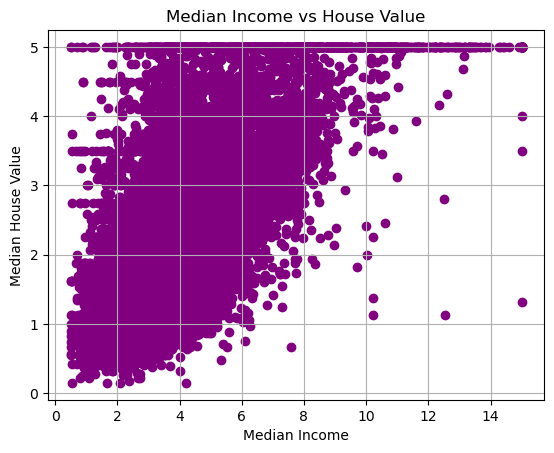

In [3]:
plt.scatter(df['MedInc'], df['MedHouseVal'], color='purple')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title('Median Income vs House Value')
plt.grid(True)
plt.show()


In [4]:
X = df[['MedInc']]  # Independent variable
y = df['MedHouseVal']  # Dependent variable

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [5]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

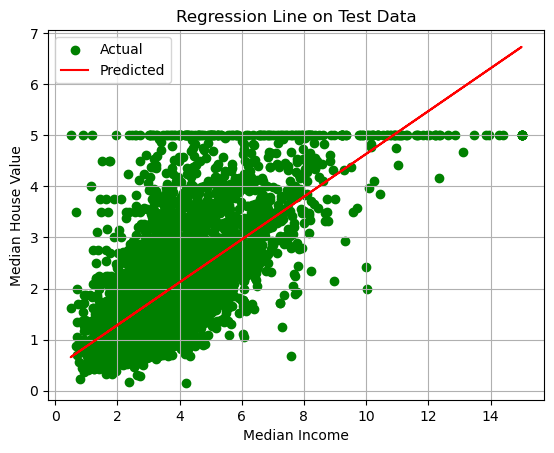

In [6]:
plt.scatter(X_test, y_test, color='green', label='Actual')
plt.plot(X_test, model.predict(X_test), color='red', label='Predicted')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title('Regression Line on Test Data')
plt.legend()
plt.grid(True)
plt.show()


In [7]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.3f}")
print(f"R² Score: {r2:.3f}")


Mean Squared Error: 0.709
R² Score: 0.459


# RIGDE REGRESSION

In [8]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

In [9]:
ridge_regressor= Ridge() # we can also we aplha parameter here , Ridge(alpha=0.1)

In [10]:
parameter = {"alpha":[0.01,0.0001,0.12,1,2,5,10,20,30,40,50,60,70,80,90]}

In [11]:
ridgecv= GridSearchCV(ridge_regressor, parameter, scoring ="neg_mean_squared_error",cv=5 )

In [12]:
ridgecv.fit(X_train, y_train) 
print(ridgecv.best_params_)

{'alpha': 10}


In [13]:
print(ridgecv.best_score_)

-0.6992830126300691


In [14]:
ridge_pred=ridgecv.predict(X_test)

In [15]:
import seaborn as sns

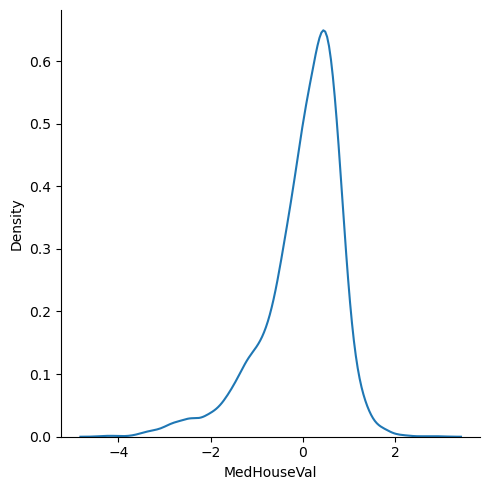

In [16]:
sns.displot(ridge_pred-y_test,kind="kde")

In [36]:
score = r2_score(ridge_pred, y_test)

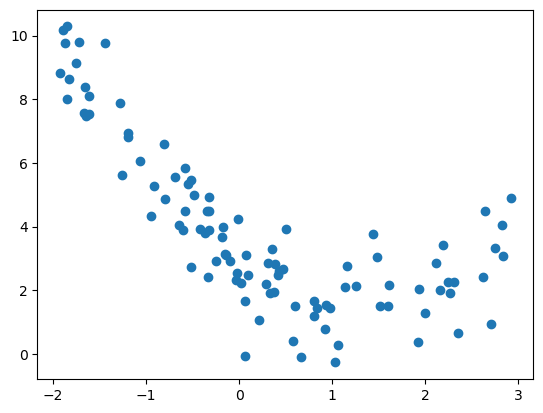

In [37]:

m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

plt.scatter(x1, x2)
plt.show()

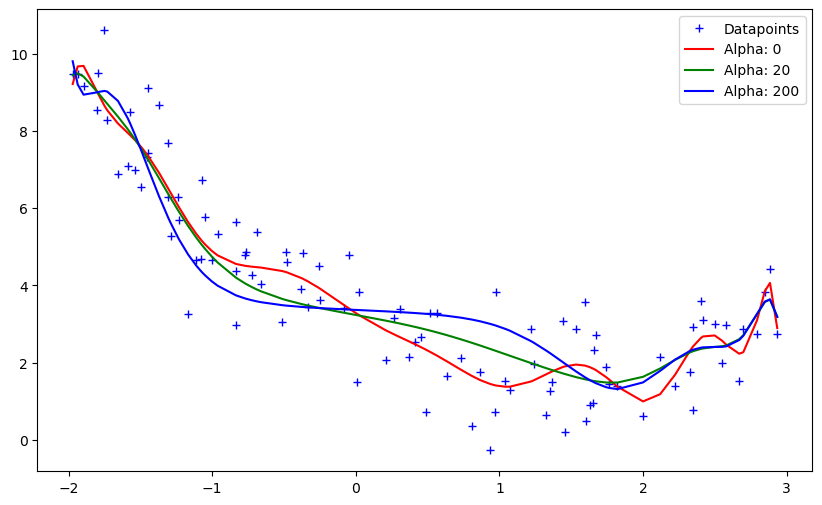

In [19]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_preds_ridge(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('ridge', Ridge(alpha=alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 20, 200]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_ridge(x1, x2, alpha)
    # Plot
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()

In [39]:
def linear_regression(X,y,alpha=1):
    x_mean = X.mean()
    y_mean = y.mean()
    
    num = 0
    den = 0
    
    for i in range(X.shape[0]):
        num = num + (y[i] - y_mean) * (X[i] - x_mean)
        den = den + (X[i] - x_mean) * (X[i] - x_mean)
        
    m = num/(den + alpha)
    b = y_mean - m*x_mean
        
    return m,b
    
class MeraRidge:
    
    def __init__(self,alpha=0.1):
        self.alpha = alpha
        self.m = None
        self.b = None
        
    def fit(self,X_train,y_train):
        
        num = 0  # numerator
        den = 0
        
        for i in range(X_train.shape[0]):
            num = num + (y_train[i] - y_train.mean())*(X_train[i] - X_train.mean())
            den = den + (X_train[i] - X_train.mean())*(X_train[i] - X_train.mean()) 
        
        self.m = num/(den + self.alpha)
        self.b = y_train.mean() - (self.m*X_train.mean())
        print(self.m,self.b)
    

In [42]:
reg = MeraRidge(alpha=10)


# For n-D data

In [48]:

class MeraRidge:
    
    def __init__(self,alpha=0.1):
        
        self.alpha = alpha
        self.coef_ = None
        self.intercept_ = None
        
    def fit(self,X_train,y_train):
        
        X_train = np.insert(X_train,0,1,axis=1)
        I = np.identity(X_train.shape[1])
        I[0][0] = 0  # as in sklearn implementation of ridge regression they keep the first col of indentity matrix 0 , so that the giev logic 
        # would not be applied to intercept column.
        # we have to apply lambda only to slopes
        result = np.linalg.inv(np.dot(X_train.T,X_train) + self.alpha * I).dot(X_train.T).dot(y_train)
        self.intercept_ = result[0]
        self.coef_ = result[1:]
    
    def predict(self,X_test):
        return np.dot(X_test,self.coef_) + self.intercept_


In [49]:

reg = MeraRidge()
reg.fit(X_train,y_train)
y_pred = reg.predict(X_test)
print(r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)

0.45885921608768887
[0.41933779]
0.44460000962414103


# Lasso regression

In [20]:
from sklearn.linear_model import Lasso

In [21]:
lasso= Lasso()

In [22]:
parameter = {"alpha":[1,2,5,10,20,30,40,50,60,70,80,90]}
lassocv= GridSearchCV(lasso, parameter, scoring ="neg_mean_squared_error",cv=5 )

In [23]:
lassocv.fit(X_train, y_train)
print(lassocv.best_score_)

-0.9751514032678671


In [24]:
print(lassocv.best_params_)

{'alpha': 1}


In [25]:
lasso_pred= lassocv.predict(X_train)

In [26]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# sns.displot(lasso_pred - y_test, kind="kde")
# plt.title("Distribution of Prediction Error (Lasso)")
# plt.xlabel("Error")
# plt.show()


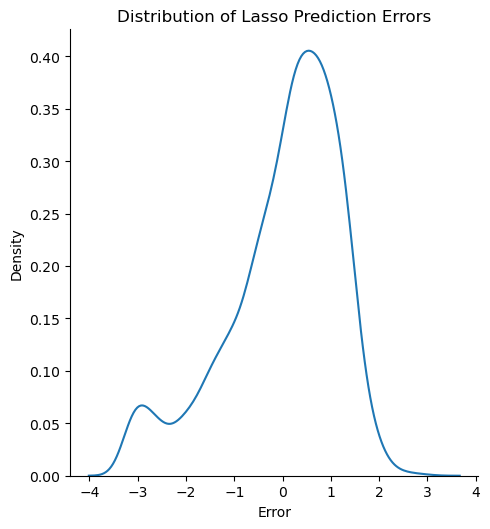

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure same length and aligned indexes
lasso_pred = pd.Series(lasso_pred).reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

# Plot prediction error distribution
sns.displot(lasso_pred - y_test, kind="kde")
plt.title("Distribution of Lasso Prediction Errors")
plt.xlabel("Error")
plt.show()


In [5]:
import numpy as  np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

In [6]:
x,y=make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1, noise=20, random_state=1)

In [9]:
x_test, x_train ,y_test ,y_train = train_test_split(x,y,test_size=0.2)

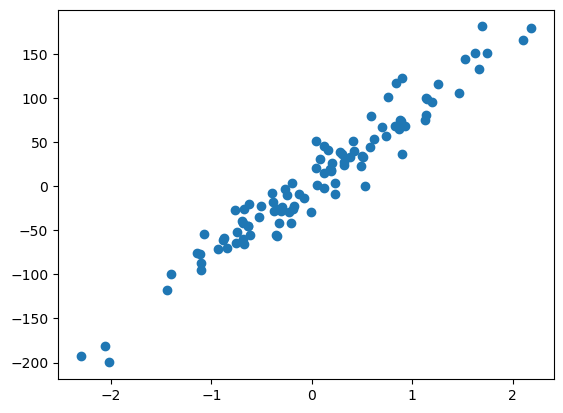

In [10]:
plt.scatter(x,y)

C:\Users\sus\anaconda3\Lib\site-packages\sklearn\base.py:1473: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
C:\Users\sus\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
C:\Users\sus\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.608e+03, tolerance: 8.170e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_desc

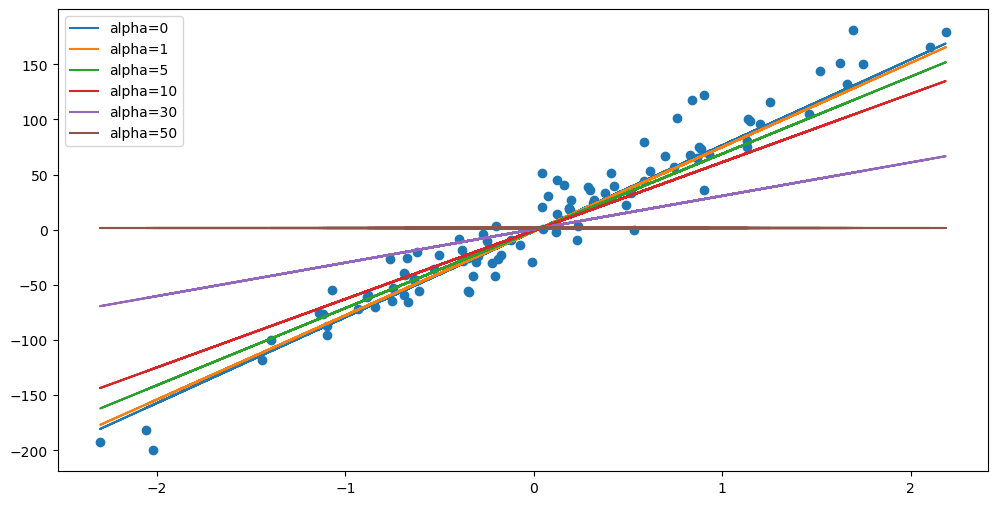

In [16]:
alpha=[0,1,5,10,30,50]
plt.figure(figsize=(12,6))
plt.scatter(x,y)
for i in alpha:
    l=Lasso(alpha=i)
    l.fit(x_train , y_train)
    plt.plot(x_test, l.predict(x_test),label="alpha={}".format(i))
plt.legend()
plt.show()


# polynomial regression

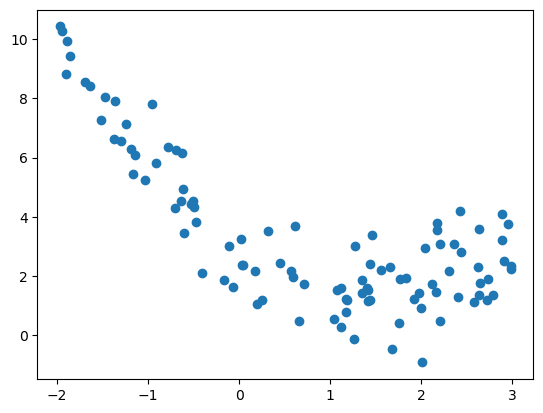

In [20]:
m=100
x1=5*np.random.rand(m,1)-2
x2=0.7*x1**2-2*x1+3+np.random.randn(m,1)
plt.scatter(x1,x2)
plt.show()

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

C:\Users\sus\anaconda3\Lib\site-packages\sklearn\base.py:1473: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
C:\Users\sus\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
C:\Users\sus\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.528e+01, tolerance: 6.595e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_desc

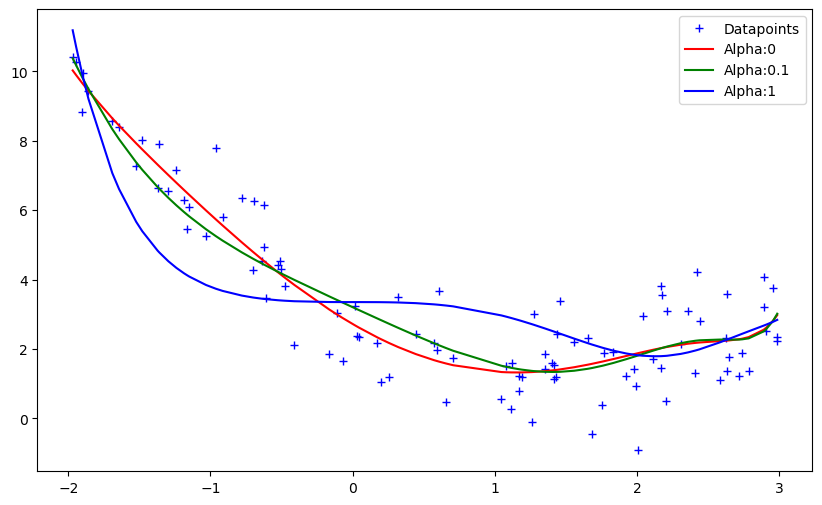

In [26]:
def get_preds_lasso(x1,x2,alpha):
    model=Pipeline([
        ("poly_feats",PolynomialFeatures(degree=16)),
        ("lasso",Lasso(alpha=alpha))
    ])
    model.fit(x1,x2)
    return model.predict(x1)
alpha=[0,0.1,1]
cs=["r","g","b"]
plt.figure(figsize=(10,6))
plt.plot(x1,x2,"b+",label="Datapoints")
for alpha , c in zip(alpha , cs):
    preds= get_preds_lasso(x1, x2, alpha)
    # plot
    plt.plot(sorted(x1[:,0]),preds[np.argsort(x1[:,0])],c , label="Alpha:{}".format(alpha))
plt.legend()
plt.show()